In [100]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

In [101]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [102]:
emissions_total_df = pd.read_csv(os.path.join(processed_data_dir_path, 'treatment_control_and_emissions_data.csv'))
agg_policies_emissions_df = pd.read_csv(os.path.join(processed_data_dir_path, 'agg_policies_and_emissions_data_by_country.csv'))

In [103]:
emissions_total_df

,iso3,year,country,policies_per_year,policies_last_3_years,income_group,prev_year_emission,avg_emissions_prev_3_years,gdp per capita,fdi net inflows (% of gdp),industry size (% of gdp),population density (people per sq km),total_emissions
0,AFG,2000,Afghanistan,0,0.0,Low income,NaN,NaN,174.930991,0.022119,23.810127,30.863847,25.390391
1,AFG,2001,Afghanistan,0,0.0,Low income,25.390391,25.390391,138.706822,0.022119,23.810127,31.099929,23.723115
2,AFG,2002,Afghanistan,0,0.0,Low income,23.723115,24.556753,178.954088,0.022119,23.810127,32.776961,26.383509
3,AFG,2003,Afghanistan,0,0.0,Low income,26.383509,25.165672,198.871116,0.022119,22.710864,34.854344,27.071538
4,AFG,2004,Afghanistan,0,0.0,Low income,27.071538,25.726054,221.763654,-0.013397,26.226790,36.123230,27.128799
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3629,ZWE,2018,Zimbabwe,0,0.0,Lower middle income,45.410983,46.390136,2271.853335,2.101721,31.037898,38.863777,47.509033
3630,ZWE,2019,Zimbabwe,1,0.0,Lower middle income,47.509033,46.277579,1684.027904,0.970160,32.025947,39.476200,46.442562
3631,ZWE,2020,Zimbabwe,0,1.0,Lower middle income,46.442562,46.454193,1730.413489,0.559626,32.767517,40.136714,44.576343
3632,ZWE,2021,Zimbabwe,1,1.0,Lower middle income,44.576343,46.175979,1724.387731,0.871791,28.805586,40.835492,45.759664


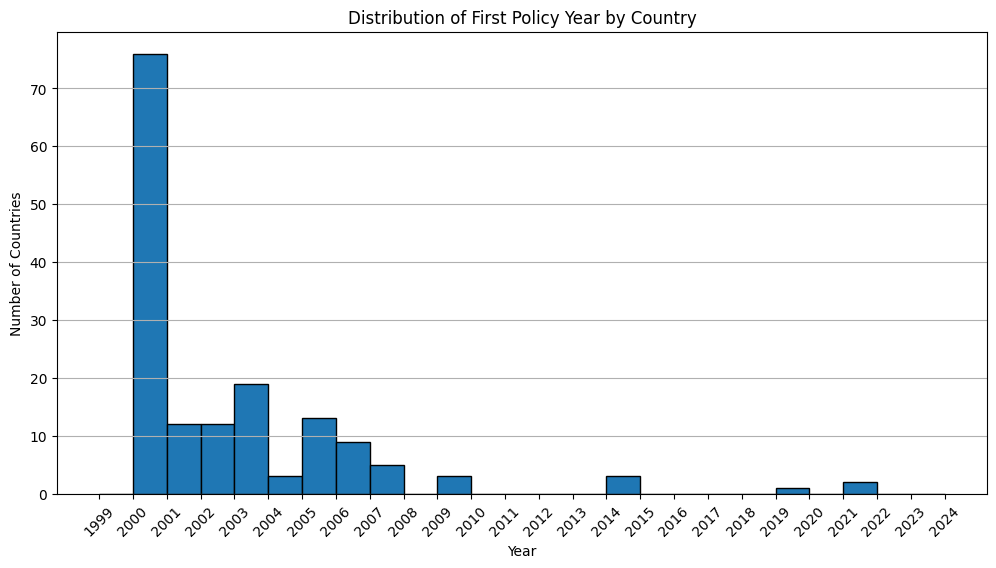

In [104]:
# Filter the rows where a policy was implemented (policies_per_year > 0)
df_policy = emissions_total_df[emissions_total_df['policies_per_year'] > 0]

# Group by country (using iso3 and country as identifiers) to find the first policy year per country
first_policy_df = df_policy.groupby(['iso3', 'country'], as_index=False)['year'].min()
first_policy_df = first_policy_df.rename(columns={'year': 'first_policy_year'})

# Sort the dataframe by the first policy year (optional, for better visualization)
first_policy_df = first_policy_df.sort_values('first_policy_year')

# Plot an histogram
plt.figure(figsize=(12, 6))
plt.hist(first_policy_df['first_policy_year'], bins=range(1999, 2025), edgecolor='black')
plt.title('Distribution of First Policy Year by Country')
plt.xlabel('Year')
plt.ylabel('Number of Countries')
plt.xticks(range(1999, 2025), rotation=45)
plt.grid(axis='y')


## Note: using the above chart as a reference for first policy is wrong since the original IEA dataset goes from ~1948

## Options for Analisis

* **Strict Control:** In a strict DiD setup, the control group remains untreated during the entire period. If some countries start having policies after 2010, you can either redefine the treatment window or use them as treated from the point they adopt policies.

* **Staggered Adoption:** If treatment timing varies, consider using an event-study design or staggered DiD methods that account for different treatment timings. This way, you compare pre- and post-treatment periods within each unit and across units with different start times.

* **Thresholds:** You might also consider defining treatment based on intensity (e.g., a minimum number of policies) rather than any policy activity, which can help distinguish between marginal policy adoptions and substantial interventions.

## Cleaning

In [105]:
# Drop unnecessary columns
emissions_total_df.drop(columns=['prev_year_emission', 'avg_emissions_prev_3_years'], inplace=True)

In [106]:
# Check for missing values
missing_values = emissions_total_df.isnull().sum()
print("Missing values in emissions_total_df:")
print(missing_values[missing_values > 0])

# Check for missing values in agg_policies_emissions_df
missing_values = agg_policies_emissions_df.isnull().sum()
print("Missing values in agg_policies_emissions_df:")
print(missing_values[missing_values > 0])


Missing values in emissions_total_df:
Series([], dtype: int64)
Missing values in agg_policies_emissions_df:
Series([], dtype: int64)


In [107]:
# Drop null values in total emissions DataFrame
emissions_total_df.dropna(inplace=True)

# Reset index
emissions_total_df.reset_index(drop=True, inplace=True)

## EDA

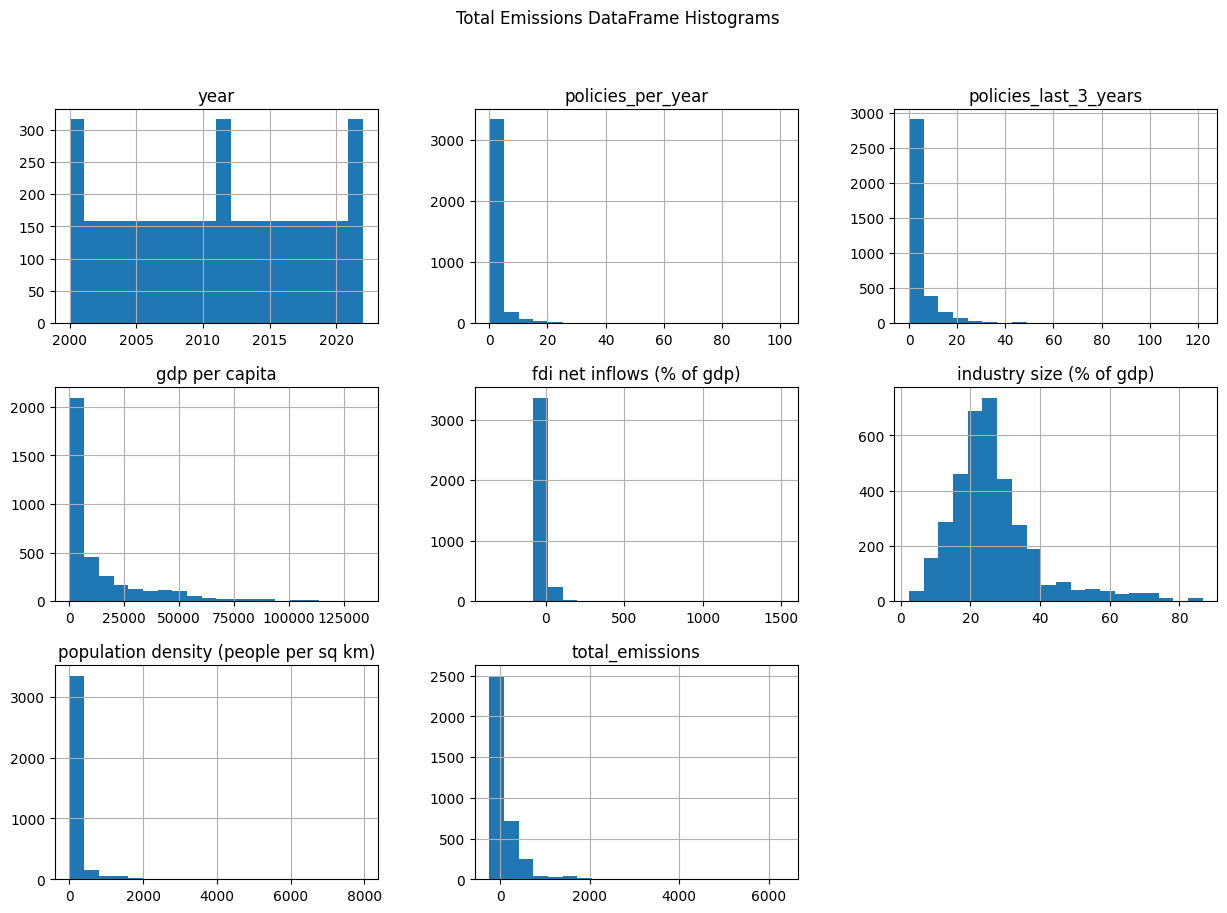

In [108]:
# Plot histograms of numeric columns
def plot_histograms(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols].hist(bins=20, figsize=(15, 10))
    plt.suptitle(title)
    plt.show()

plot_histograms(emissions_total_df, 'Total Emissions DataFrame Histograms')

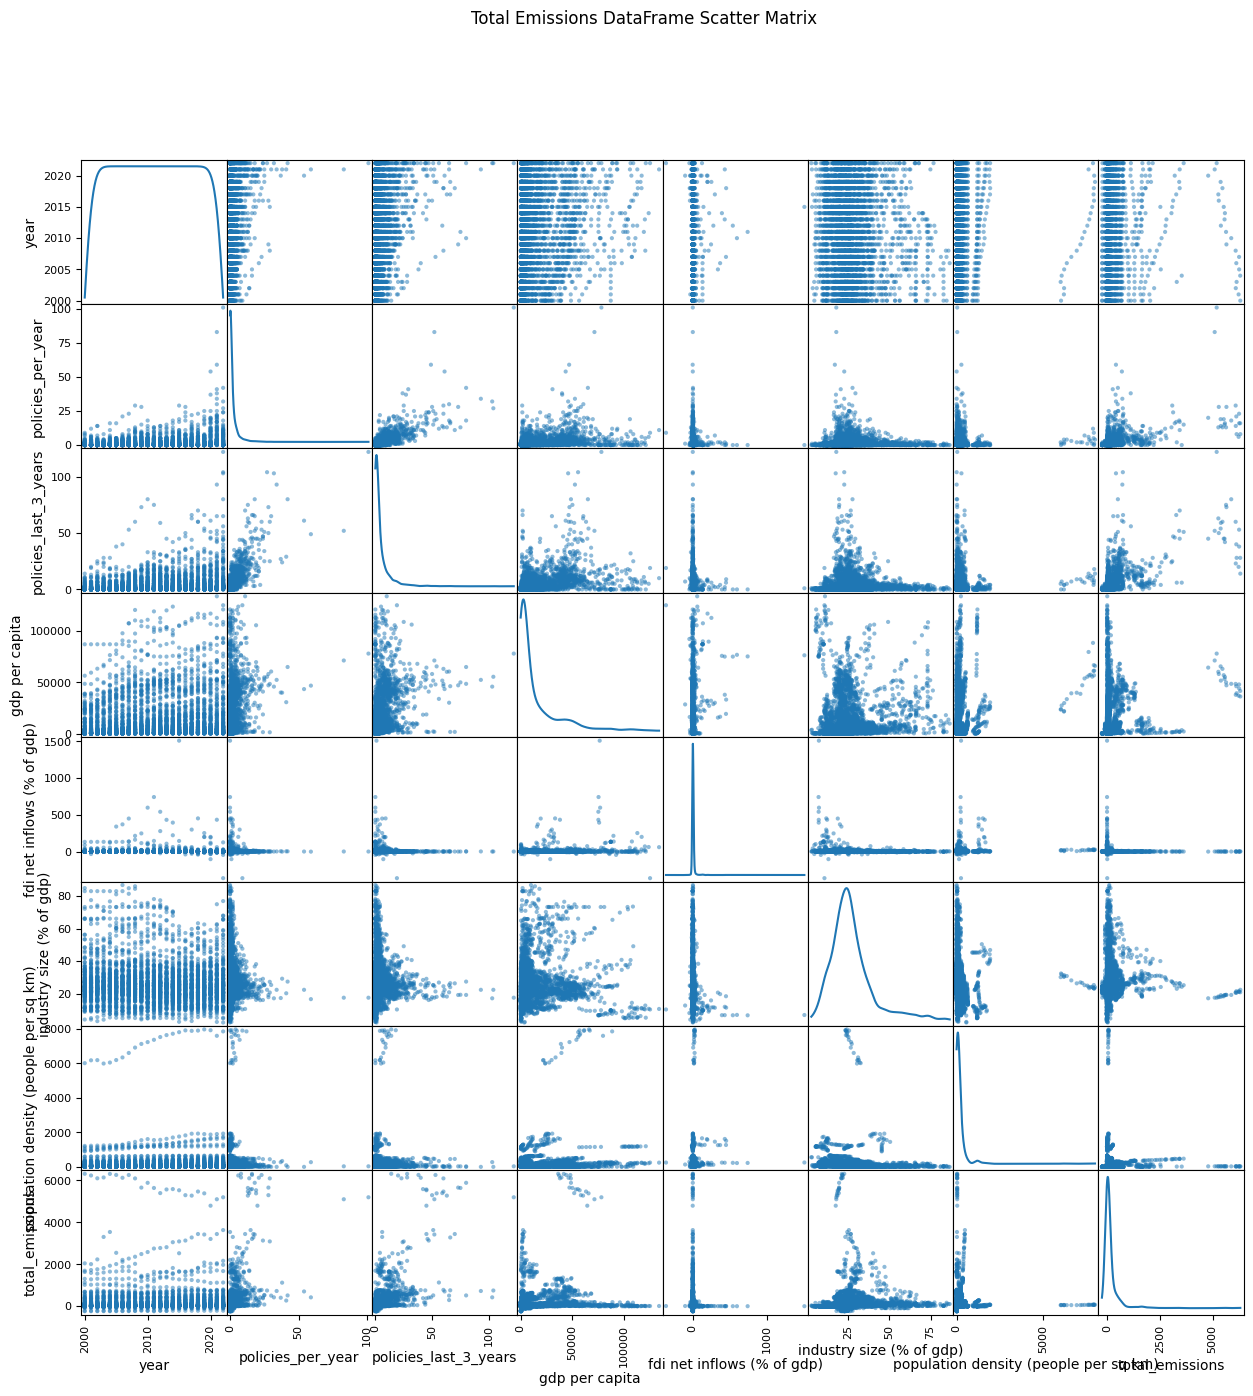

In [109]:
# Plot scatter plots of numeric columns
def plot_scatter_matrix(df, title):
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    pd.plotting.scatter_matrix(df[numeric_cols], figsize=(15, 15), diagonal='kde')
    plt.suptitle(title)
    plt.show()
plot_scatter_matrix(emissions_total_df, 'Total Emissions DataFrame Scatter Matrix')


## Strict Control

In [110]:
df_test = emissions_total_df[emissions_total_df.policies_per_year > 0]
# Get min year per country
min_year_per_country = df_test.groupby('country')['year'].min().reset_index()
min_year_per_country = min_year_per_country.rename(columns={'year': 'first_policy_year'})
min_year_per_country

,country,first_policy_year
0,Afghanistan,2006
1,Albania,2002
2,Algeria,2003
3,Angola,2000
4,Antigua and Barbuda,2005
...,...,...
153,Uzbekistan,2009
154,Vanuatu,2003
155,Viet Nam,2000
156,Zambia,2000


In [111]:
control_group = min_year_per_country[min_year_per_country['first_policy_year'] > 2008]
control_group

,country,first_policy_year
17,Bermuda,2014
30,Cayman Islands,2014
52,French Polynesia,2014
79,Kuwait,2009
103,New Caledonia,2009
111,Palau,2021
135,Sudan,2021
142,Timor-Leste,2019
153,Uzbekistan,2009


In [112]:
treatment_group = min_year_per_country[min_year_per_country['first_policy_year'] <= 2008]
treatment_group

,country,first_policy_year
0,Afghanistan,2006
1,Albania,2002
2,Algeria,2003
3,Angola,2000
4,Antigua and Barbuda,2005
...,...,...
152,Uruguay,2002
154,Vanuatu,2003
155,Viet Nam,2000
156,Zambia,2000


In [113]:
!pip install statsmodels

In [114]:
emissions_total_df.head()

,iso3,year,country,policies_per_year,policies_last_3_years,income_group,gdp per capita,fdi net inflows (% of gdp),industry size (% of gdp),population density (people per sq km),total_emissions
0,AFG,2000,Afghanistan,0,0.0,Low income,174.930991,0.022119,23.810127,30.863847,25.390391
1,AFG,2001,Afghanistan,0,0.0,Low income,138.706822,0.022119,23.810127,31.099929,23.723115
2,AFG,2002,Afghanistan,0,0.0,Low income,178.954088,0.022119,23.810127,32.776961,26.383509
3,AFG,2003,Afghanistan,0,0.0,Low income,198.871116,0.022119,22.710864,34.854344,27.071538
4,AFG,2004,Afghanistan,0,0.0,Low income,221.763654,-0.013397,26.226790,36.123230,27.128799


In [115]:
emissions_total_df.rename(columns={'industry size (% of gdp)': 'industry_size',
                                   'population density (people per sq km)':'pop_density',
                                   'gdp per capita':'gdp_per_capita',
                                   'fdi net inflows (% of gdp)': 'fdi_new_inflows'}, inplace=True)

emissions_total_df = emissions_total_df.drop(columns='policies_last_3_years')
emissions_total_df

,iso3,year,country,policies_per_year,income_group,gdp_per_capita,fdi_new_inflows,industry_size,pop_density,total_emissions
0,AFG,2000,Afghanistan,0,Low income,174.930991,0.022119,23.810127,30.863847,25.390391
1,AFG,2001,Afghanistan,0,Low income,138.706822,0.022119,23.810127,31.099929,23.723115
2,AFG,2002,Afghanistan,0,Low income,178.954088,0.022119,23.810127,32.776961,26.383509
3,AFG,2003,Afghanistan,0,Low income,198.871116,0.022119,22.710864,34.854344,27.071538
4,AFG,2004,Afghanistan,0,Low income,221.763654,-0.013397,26.226790,36.123230,27.128799
...,...,...,...,...,...,...,...,...,...,...
3629,ZWE,2018,Zimbabwe,0,Lower middle income,2271.853335,2.101721,31.037898,38.863777,47.509033
3630,ZWE,2019,Zimbabwe,1,Lower middle income,1684.027904,0.970160,32.025947,39.476200,46.442562
3631,ZWE,2020,Zimbabwe,0,Lower middle income,1730.413489,0.559626,32.767517,40.136714,44.576343
3632,ZWE,2021,Zimbabwe,1,Lower middle income,1724.387731,0.871791,28.805586,40.835492,45.759664


In [116]:
import pandas as pd
import statsmodels.formula.api as smf

# Assuming your full dataset is in emissions_total_df
# Step 1: Identify countries with at least one policy and compute their first policy year.
df_test = emissions_total_df[emissions_total_df.policies_per_year > 0]
min_year_per_country = df_test.groupby('country')['year'].min().reset_index()
min_year_per_country = min_year_per_country.rename(columns={'year': 'first_policy_year'})

# Step 2: Define treatment and control groups.
# Treatment: first policy year is <= 2008, Control: first policy year is > 2008
treatment_countries = min_year_per_country[min_year_per_country['first_policy_year'] <= 2008]['country']
control_countries = min_year_per_country[min_year_per_country['first_policy_year'] > 2008]['country']

# Step 3: Subset the full dataset to the desired analysis period.
# Here we use data from 2000 to 2008.
analysis_df = emissions_total_df[emissions_total_df['year'] <= 2008].copy()

# Step 4: Create the binary treatment indicator.
# For each observation, treatment = 1 if the country is in the treatment group.
analysis_df['treatment'] = analysis_df['country'].isin(treatment_countries).astype(int)

# Step 5: Define the post-treatment period.
# For this example, we assume a post-treatment period starts at 2004.
policy_year = 2004
analysis_df['post'] = (analysis_df['year'] >= policy_year).astype(int)

# (Optional) Check the first few rows to verify the new columns.
print(analysis_df[['country', 'year', 'treatment', 'post']].head(10))

# Step 6: Run the DiD regression model with additional controls.
model = smf.ols(
    'total_emissions ~ treatment * post + gdp_per_capita + fdi_new_inflows + industry_size + pop_density',
    data=analysis_df
).fit()

# View the regression results.
print(model.summary())


        country  year  treatment  post
0   Afghanistan  2000          1     0
1   Afghanistan  2001          1     0
2   Afghanistan  2002          1     0
3   Afghanistan  2003          1     0
4   Afghanistan  2004          1     1
5   Afghanistan  2005          1     1
6   Afghanistan  2006          1     1
7   Afghanistan  2007          1     1
8   Afghanistan  2008          1     1
23       Angola  2000          1     0
                            OLS Regression Results                            
Dep. Variable:        total_emissions   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     9.198
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           3.66e-11
Time:                        15:37:57   Log-Likelihood:                -11057.
No. Observations:                1422   AIC:                         2.213e+04
Df Residuals:     

## Staggered

In [117]:
import pandas as pd
import statsmodels.formula.api as smf

# Assume your DataFrame is named df and has the columns shown:
# iso3, year, country, policies_per_year, income_group, gdp_per_capita, fdi_new_inflows, industry_size, pop_density, total_emissions

# 1. Compute the first policy year for each country that has at least one policy.
df_treated = emissions_total_df[emissions_total_df['policies_per_year'] > 0]
first_policy = df_treated.groupby('country')['year'].min().reset_index()
first_policy.rename(columns={'year': 'first_policy_year'}, inplace=True)

# Merge the treatment timing back into the full dataset.
df = pd.merge(emissions_total_df, first_policy, on='country', how='left')
# Countries that never implement a policy will have NaN for first_policy_year.

# 2. Create a "relative_year" variable.
df['relative_year'] = df['year'] - df['first_policy_year']

# 3. Bin the relative years.
# For never-treated countries, assign a unique label; group extreme values for treated ones.
def bin_relative_year(ry):
    if pd.isna(ry):
        
        return 'never'
    elif ry < -5:
        return '<=-5'
    elif ry > 5:
        return '>=5'
    else:
        return str(int(ry))

df['rel_time_bin'] = df['relative_year'].apply(bin_relative_year)

# Optional: Check the distribution of the binned relative years.
print(df[['country', 'year', 'first_policy_year', 'relative_year', 'rel_time_bin']].head(15))

# 4. Run the event study regression.
# Use the binned relative time as a categorical variable (with "-1" as the reference category).
# Include additional time-varying controls: gdp_per_capita, fdi_new_inflows, industry_size, and pop_density.
# Also include fixed effects for country and year.
formula = (
    'total_emissions ~ C(rel_time_bin, Treatment(reference="-1")) '
    '+ gdp_per_capita + fdi_new_inflows + industry_size + pop_density '
    '+ C(country) + C(year)'
)

# Run the OLS regression and cluster standard errors by country.
model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['country']})

# Display the regression results.
print(model.summary())


        country  year  first_policy_year  relative_year rel_time_bin
0   Afghanistan  2000               2006             -6         <=-5
1   Afghanistan  2001               2006             -5           -5
2   Afghanistan  2002               2006             -4           -4
3   Afghanistan  2003               2006             -3           -3
4   Afghanistan  2004               2006             -2           -2
5   Afghanistan  2005               2006             -1           -1
6   Afghanistan  2006               2006              0            0
7   Afghanistan  2007               2006              1            1
8   Afghanistan  2008               2006              2            2
9   Afghanistan  2009               2006              3            3
10  Afghanistan  2010               2006              4            4
11  Afghanistan  2011               2006              5            5
12  Afghanistan  2012               2006              6          >=5
13  Afghanistan  2013             

/home/tony-ubuntu/anaconda3/envs/cpia_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 195, but rank is 38
  warnings.warn('covariance of constraints does not have full '
